<a href="https://colab.research.google.com/github/sayak395/Jaynes-Cummings-model/blob/main/RL_with_Hamiltonian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qutip

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options, expect, ptrace)
from scipy.signal import find_peaks

from scipy.interpolate import CubicSpline, PchipInterpolator
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.plots import plot_convergence
from skopt.utils import use_named_args
from scipy.optimize import minimize
from functools import lru_cache
from random import uniform
from gym import Env, spaces

!pip install stable-baselines3
from stable_baselines3 import PPO
!pip install shimmy>=2.0

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 143.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Hilbert space dimension for the cavity
n_cavity = 5
sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

wc = wa = 1.0  # Example values
g = 0.01 * wc

In [3]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()

target_state_0 = tensor(fock(n_cavity, 1), spin_down)
target_den_0 = target_state_0 * target_state_0.dag()
target_state_1 = tensor(fock(n_cavity, 1), spin_up)
target_den_1 = target_state_1 * target_state_1.dag()

In [26]:
# === DRIVEN JC OBJECTIVE PLACEHOLDER ===
def objective_general(y1, y2, y3, dx1, dx2, dx3, sim_time, FracHold, FX1, FY1):

    tau = wc * sim_time
    x1 = tau * dx1
    x2 = tau * dx2
    x3 = tau * dx3
    t_h = tau * FracHold
    fx1 = tau * FX1

    if not (0 < x1 < x2 < 1):
        return 1.0
    if not (0 < FracHold < FX1 < 1):
        return 1.0

    envelope_spline = CubicSpline(
            [0, x1, x2, x3, tau],
            [0, y1, y2, y3, 0],
            extrapolate=False
        )
    if np.nanmax(np.abs(envelope_spline(np.linspace(0, tau, 101)))) > A_MAX:
        return 1.0

    frequency_spline = CubicSpline(
        [0, 0.25*t_h, 0.5*t_h, 0.75*t_h, t_h, fx1],
        [wa, wa, wa, wa, wa, FY1]
    )

    args = {'envelope': envelope_spline, 'frequency': frequency_spline}

    H_static = g * (a.dag() * sigma_minus + a * sigma_plus)
    H = [
        H_static,
        [a.dag() * a, lambda t, args: delta_c_t(t, args)],
        [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
        [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
    ]

    try:
        result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[],
                          options={'nsteps': 1e6, 'atol': 1e-6, 'rtol': 1e-6},
                          args=args)
        final_rho = result.states[-1]
        #rho_cavity = final_rho.ptrace(0)
        fidelity_down = fidelity(target_den_0, final_rho)**2
        fidelity_up = fidelity(target_den_1, final_rho)**2
        fidelity_custom = fidelity_down + fidelity_up
        #fidelity_custom = fidelity(target_den_0, rho_cavity)**2

        return 1 - fidelity_custom

    except Exception as e:
        print("Simulation error:", e)
        return 1.0

# === PARAMETER BOUNDS ===
original_bounds = [
    Real(0.5*g, 2.5*g, name='Y1'),
    Real(-g, g, name="Y2"),
    Real(0*g, g, name="Y3"),
    Real(0.2, 0.25, name='ΔX1'),
    Real(0.8, 0.84, name='ΔX2'),
    Real(0.841, 0.86, name='ΔX3'),
    Real(3/g, 6/g, name="SimTime"),
    Real(0.3, 0.7, name='FracHold'),
    Real(0.95, 1, name='FX1'),
    Real(0.95*wa, 1.1*wa, name = 'FY1')
]

# === META-BO ENVIRONMENT ===
class MetaBOEnv(Env):
    """
    Reinforcement Learning environment that trains an agent to modify bounds for Bayesian Optimization
    over the 10 control parameters of the driven JC system.
    """
    def __init__(self, original_bounds, n_calls=150):
        super().__init__()
        self.n_params = len(original_bounds)
        self.original_bounds = np.array([(b.low, b.high) for b in original_bounds])
        self.action_space = spaces.Box(low=0, high=1, shape=(2 * self.n_params,), dtype=np.float32)
        self.observation_space = self.action_space
        self.n_calls = n_calls

    def reset(self):
        return self.action_space.sample()

    def step(self, action):
        bounds_scaled = []

        for i in range(self.n_params):
            l_orig, u_orig = self.original_bounds[i]
            l_rel = action[2*i]
            u_rel = action[2*i + 1]

            # Convert normalized action into real bounds and sort
            l_new, u_new = sorted([
                l_orig + l_rel * (u_orig - l_orig),
                l_orig + u_rel * (u_orig - l_orig)
            ])

            # Skip if bounds are too narrow
            if (u_new - l_new) < 1e-4:
                return action, -10.0, True, {}

            bounds_scaled.append((l_new, u_new))

        # Define search space
        space = [Real(l, u, name=f"param_{i}") for i, (l, u) in enumerate(bounds_scaled)]

        # Objective for gp_minimize
        def objective_wrapper(x):
            return objective_general(*x)

        try:
            res_gp = gp_minimize(objective_wrapper, space, n_calls=self.n_calls, random_state=42,
                         verbose=True, acq_func='LCB', noise=0.01)

            # === Local refinement with L-BFGS-B ===
            space_bounds = [(dim.low, dim.high) for dim in space]

            def scipy_objective(x):
                return objective_general(*x)

            res_local = minimize(
                scipy_objective,
                res_gp.x,
                method='L-BFGS-B',
                bounds=space_bounds,
                options={'disp': True, 'maxiter': 500}
            )

            print("\n=== Local Refinement Result ===")

            print("Best infidelity:", res_local.fun)


            reward = -res_local.fun  # Higher fidelity = higher reward
        except Exception as e:
            print("BO failed:", e)
            reward = -10.0

        return action, reward, True, {}

In [27]:
env = MetaBOEnv(original_bounds=original_bounds, n_calls=25)


model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0010
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0007
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0007
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0007
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.00

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Time taken: 0.0010
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.0009
Function value obtained: 1.0000
Current minimum: 1.0000
Iteration No: 6 started. Evaluating function at random point.
Iteration No: 6 ended. Evaluation done a

In [22]:
A_MAX = 3 * g

# === TIME-DEPENDENT FUNCTIONS ===
def f_t(t, args):
    return float(args['envelope'](t))

def delta_c_t(t, args):
    return wc - float(args['frequency'](t))

def delta_a_t(t, args):
    return wa - float(args['frequency'](t))

# === MAIN SIMULATION + PLOTTING FUNCTION ===
def run_sim_and_plot_all(params, res_gp_vals=None, res_local_val=None):
    Y1, Y2, Y3, dX1, dX2, dX3, SimTime, FracHold, FX1, FY1 = params
    tau = wc * SimTime
    X1 = tau * dX1
    X2 = tau * dX2
    X3 = tau * dX3
    t_h = tau * FracHold
    FX1 = tau * FX1
    tau_arr = np.linspace(0, tau, 5000)

    envelope_spline = CubicSpline([0, X1, X2, tau], [0, Y1, Y2, 0])
    frequency_spline = CubicSpline([0, 0.25*t_h, 0.5*t_h, 0.75*t_h, t_h, FX1], [wa, wa, wa, wa, wa, FY1])
    envelope = envelope_spline(tau_arr)
    omega_t = frequency_spline(tau_arr)
    phase = np.cumsum(omega_t) * np.diff(tau_arr, prepend=0)

    args = {'envelope': envelope_spline, 'frequency': frequency_spline}
    H_static = g * (a.dag() * sigma_minus + a * sigma_plus)
    H = [
        H_static,
        [a.dag() * a, lambda t, args: delta_c_t(t, args)],
        [0.5 * sigma_z, lambda t, args: delta_a_t(t, args)],
        [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
    ]

    output = mesolve(H, psi, tau_arr, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus],
                     args=args, options=Options(nsteps=int(1e7), atol=1e-7, rtol=1e-7, store_states=True))

    n_c = output.expect[0]
    n_a = output.expect[1]

    # Envelope + Phase
    plt.figure(figsize=(10, 6))
    plt.plot(tau_arr, envelope * np.cos(phase), label=r'$\phi(t)$')
    plt.plot(tau_arr, envelope, '--', label='Envelope')
    plt.scatter([X1, X2], [Y1, Y2], marker='x', color='black', label='Control Points')
    plt.axhline(A_MAX, color='r', linestyle='--')
    plt.axhline(-A_MAX, color='r', linestyle='--')
    plt.title('Envelope and Modulated Signal')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Occupations
    plt.figure(figsize=(10, 6))
    plt.plot(tau_arr, n_c, label='Cavity Photon')
    plt.plot(tau_arr, n_a, label='Atom Excited')
    plt.title('Occupation Dynamics')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Frequency
    plt.figure(figsize=(10, 6))
    plt.plot(tau_arr, omega_t, label=r'$\omega(t)$', linewidth=2)
    plt.scatter([t_h, FX1], [wa, FY1], color='black', marker='x', s=80, label='Frequency Control Point')
    plt.title('Time-Dependent Frequency')
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Detunings
    delta_c = wc - omega_t
    delta_a = wa - omega_t
    plt.figure(figsize=(10, 6))
    plt.plot(tau_arr, delta_c, label='Δc(t)')
    plt.plot(tau_arr, delta_a, label='Δa(t)')
    plt.axhline(0, color='k', linestyle='--')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Fock Populations
    fock_pop = {n: [] for n in range(n_cavity)}
    for state in output.states:
        for n in range(n_cavity):
            proj = tensor(fock(n_cavity, n).proj(), qeye(2))
            fock_pop[n].append(expect(proj, state))

    plt.figure(figsize=(10, 6))
    for n in range(n_cavity):
        plt.plot(tau_arr, fock_pop[n], label=f'Fock {n}')
    plt.title("Cavity Fock Populations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Convergence plot (if provided)
    if res_gp_vals is not None and res_local_val is not None:
        plt.figure(figsize=(10, 6))
        plt.semilogy(range(len(res_gp_vals)), res_gp_vals, label='Bayesian Optimization', lw=2)
        plt.axhline(res_local_val, color='r', linestyle='--', label=f'L-BFGS-B Final: {res_local_val:.4e}')
        plt.plot(len(res_gp_vals), res_gp_vals[-1], 'ro', label='L-BFGS-B Start')
        plt.xlabel('Function evaluations')
        plt.ylabel('Infidelity (log scale)')
        plt.title('Convergence of Infidelity')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

    plt.show()



def plot_action_bounds(action, original_bounds):
    import matplotlib.pyplot as plt

    n_params = len(original_bounds)
    fig, ax = plt.subplots(figsize=(12, 5))

    for i, bound in enumerate(original_bounds):
        l_orig = bound.low
        u_orig = bound.high

        l_rel = action[2 * i]
        u_rel = action[2 * i + 1]

        l_abs = l_orig + l_rel * (u_orig - l_orig)
        u_abs = l_orig + u_rel * (u_orig - l_orig)

        ax.plot([i, i], [l_orig, u_orig], color='gray', lw=2)      # Original full range
        ax.plot([i, i], [l_abs, u_abs], color='blue', lw=6)        # RL-compressed bounds

    ax.set_xticks(range(n_params))
    ax.set_xticklabels([b.name for b in original_bounds], rotation=45)
    ax.set_title("RL-Adjusted Parameter Bounds")
    ax.set_ylabel("Parameter Value")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

def extract_params_from_action(action, original_bounds):
    best_params = []
    for i, bound in enumerate(original_bounds):
        l_orig = bound.low
        u_orig = bound.high

        l_rel = action[2 * i]
        u_rel = action[2 * i + 1]

        l_abs = l_orig + l_rel * (u_orig - l_orig)
        u_abs = l_orig + u_rel * (u_orig - l_orig)

        midpoint = 0.5 * (l_abs + u_abs)
        best_params.append(midpoint)

    return best_params




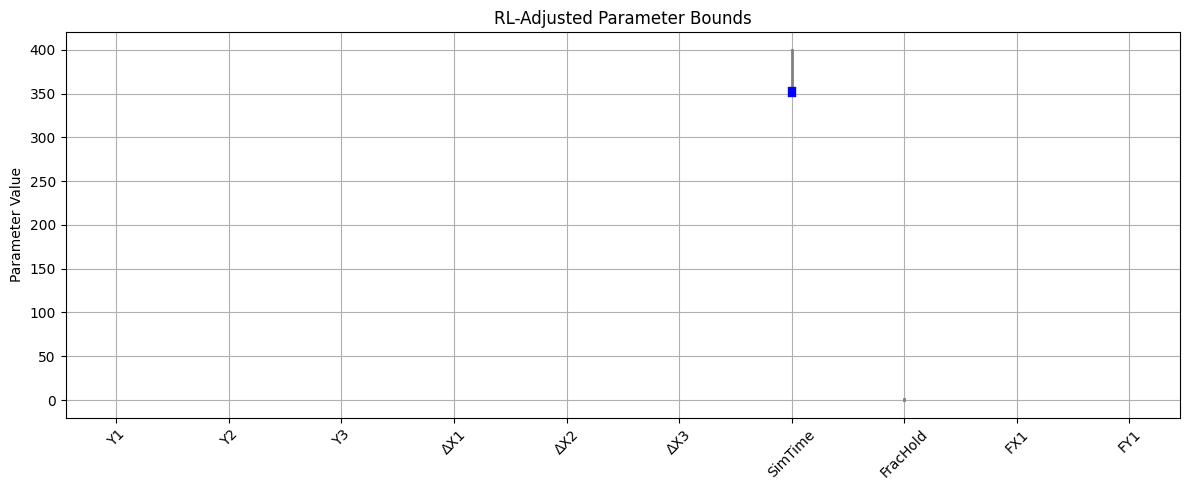

/usr/local/lib/python3.11/dist-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


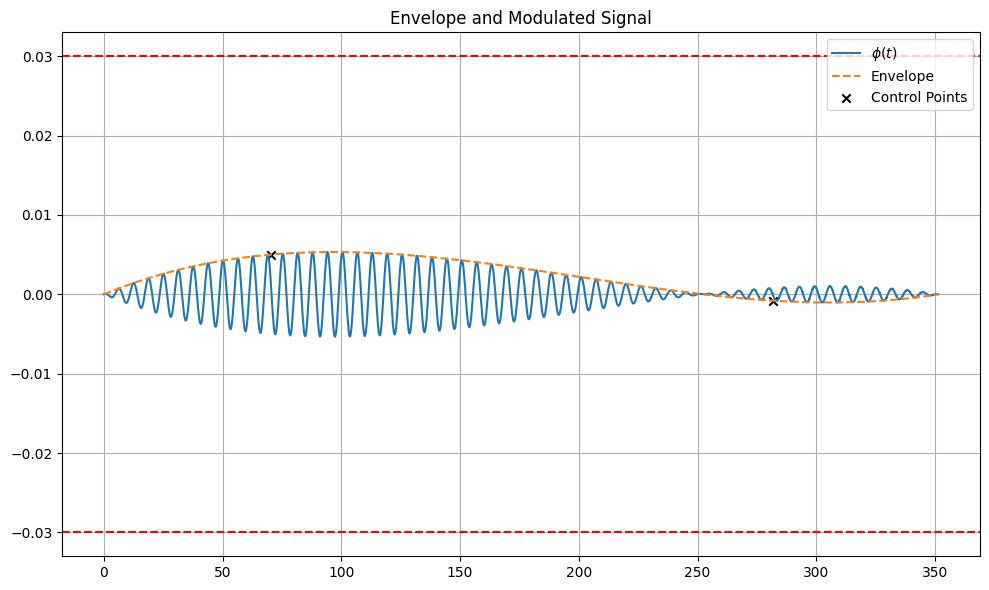

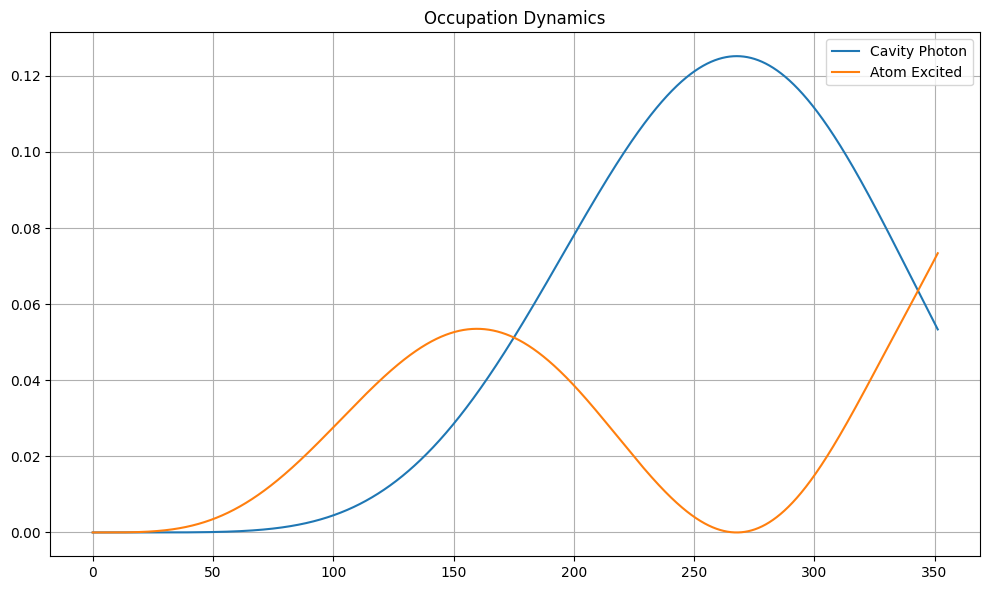

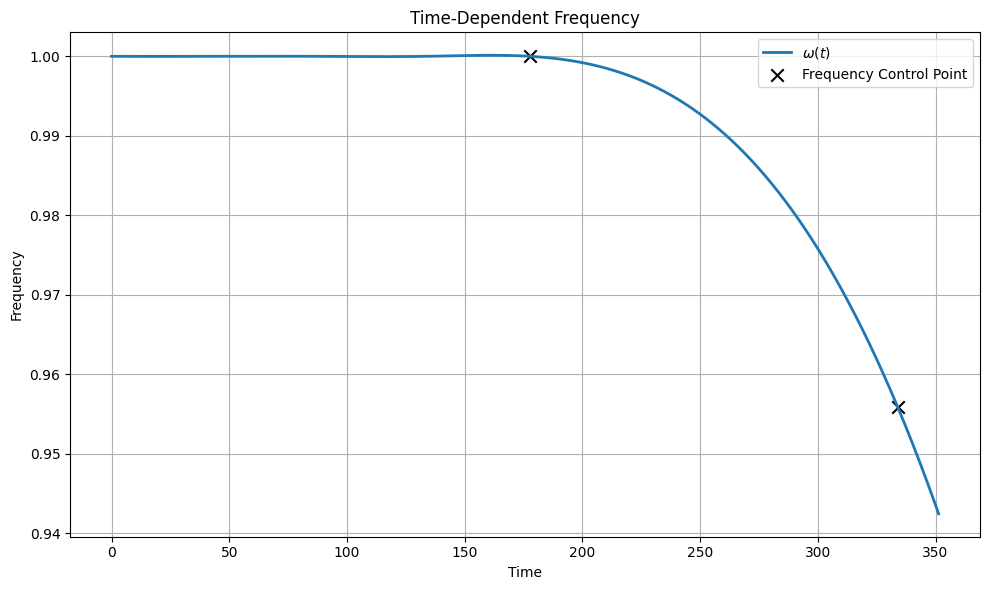

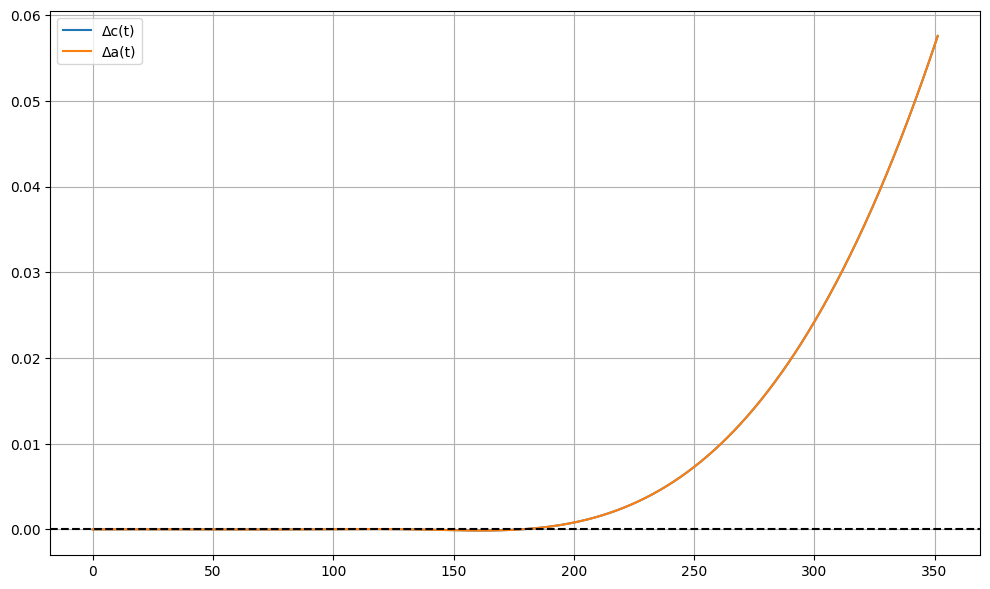

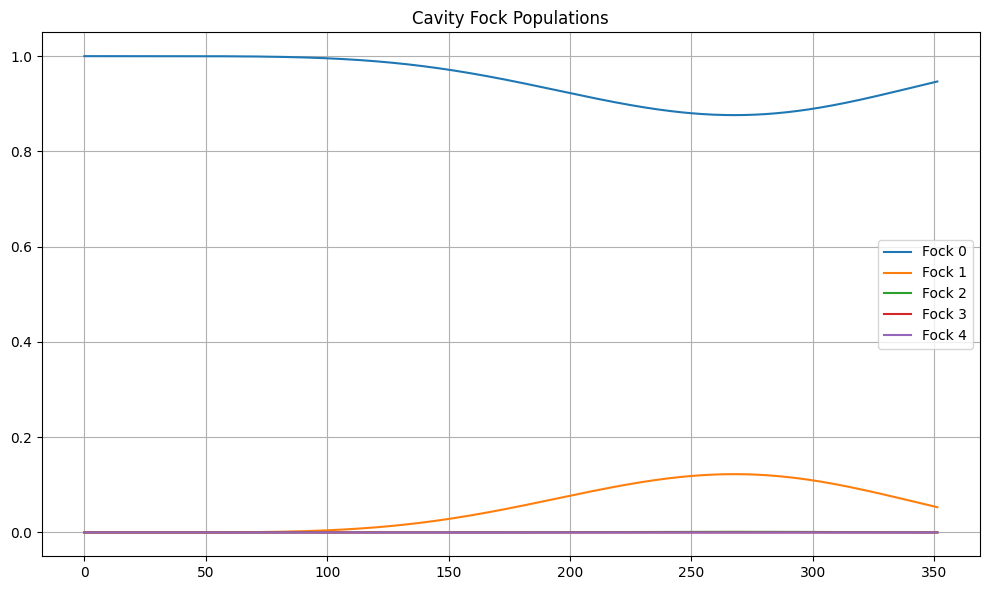

In [23]:
best_action, _ = model.predict(env.reset(), deterministic=True)

plot_action_bounds(best_action, original_bounds)
params = extract_params_from_action(best_action, original_bounds)
run_sim_and_plot_all(params)

